# Setting up a GNN

In [ ]:
pip install torch_geometric networkx torchinfo h5py

  Using cached torch_geometric-2.8.0-py3-none-any.whl.metadata (64 kB)
  Using cached torchinfo-1.8.0-py3-none-any.whl.metadata (21 kB)
Using cached torch_geometric-2.8.0-py3-none-any.whl (1.3 MB)
Using cached torchinfo-1.8.0-py3-none-any.whl (23 kB)


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics as metrics
from sklearn.neighbors import kneighbors_graph

import torch
import torchinfo
import torch.nn as nn

from torch_geometric.nn import conv, global_mean_pool
from torch_geometric.nn.norm import BatchNorm
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

import h5py
from google.colab import drive

## Checking available cpus/gpus

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')


if device == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
elif device == 'mps':
    print('Using Apple Metal Performance Shaders')
else:
    print('Using CPU')

Using device: cuda
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


## Defining files and loading spacepoints

In [ ]:
drive.mount('/content/drive')

training_file = "/content/drive/MyDrive/Colab Notebooks/MPID_training_set_full.h5"
test_file = "/content/drive/MyDrive/Colab Notebooks/MPID_test_set_full.h5"

Mounted at /content/drive


In [ ]:
def load_hdf5_data(hdf5_file):
    data_list = []
    with h5py.File(hdf5_file, 'r') as f:
        for key in f.keys():
            spacepoints = f[key]['spacepoints'][:]
            label = f[key].attrs['label']
            data_list.append({'spacepoints': spacepoints, 'label': label})
    return data_list

In [ ]:
all_data = load_hdf5_data(training_file)
print(f"Training data loaded: {len(all_data)} events")

test_data_raw = load_hdf5_data(test_file)
print(f"Test data loaded: {len(test_data_raw)} events")

Training data loaded: 62879 events
Test data loaded: 6911 events


## Visualising events

### Point cloud

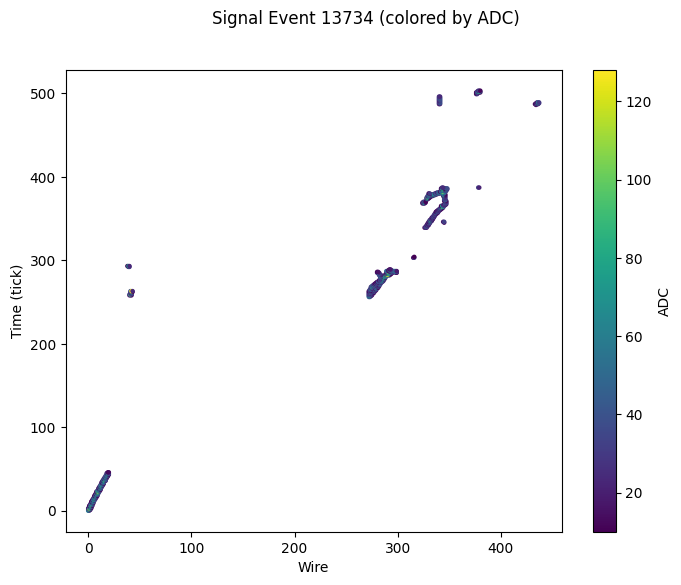

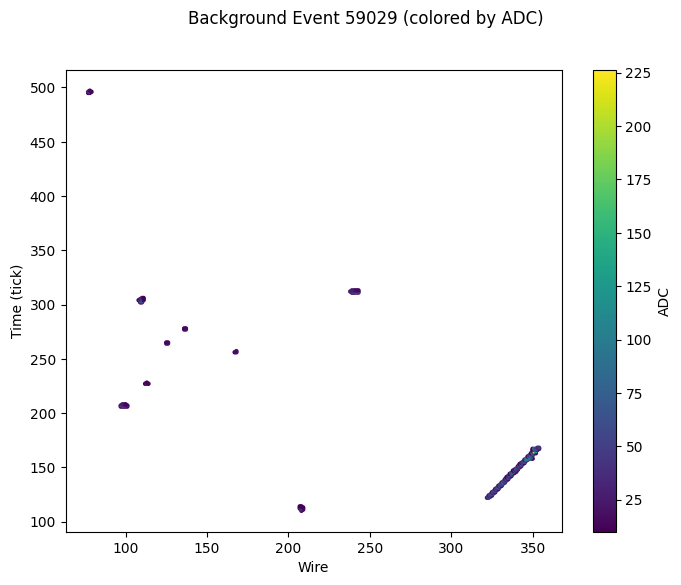

In [ ]:
import random
sig_indices = [i for i, d in enumerate(all_data) if d['label'] == 1]
bkg_indices = [i for i, d in enumerate(all_data) if d['label'] == 0]

sig_event_index = random.choice(sig_indices)
bkg_event_index = random.choice(bkg_indices)

def plot_spacepoints(data_list, event_index, title_prefix=''):
    sp = data_list[event_index]['spacepoints']
    wire = sp[:, 0]
    time = sp[:, 1]
    charge = sp[:, 2]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sc = ax.scatter(wire, time, c=charge, cmap='viridis', s=5)
    plt.colorbar(sc, ax=ax, label='ADC')
    ax.set_xlabel('Wire')
    ax.set_ylabel('Time (tick)')
    fig.suptitle(f'{title_prefix} Event {event_index} (colored by ADC)')
    plt.show()

plot_spacepoints(all_data, sig_event_index, title_prefix='Signal')
plot_spacepoints(all_data, bkg_event_index, title_prefix='Background')

### kNN Graph

You could also combine the list of edges with the the pointcloud to show these connections in 3D space, but I find it quite hard to parse.

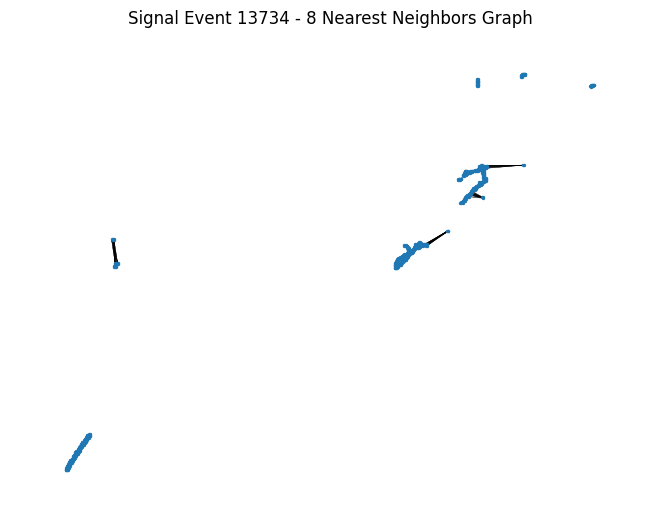

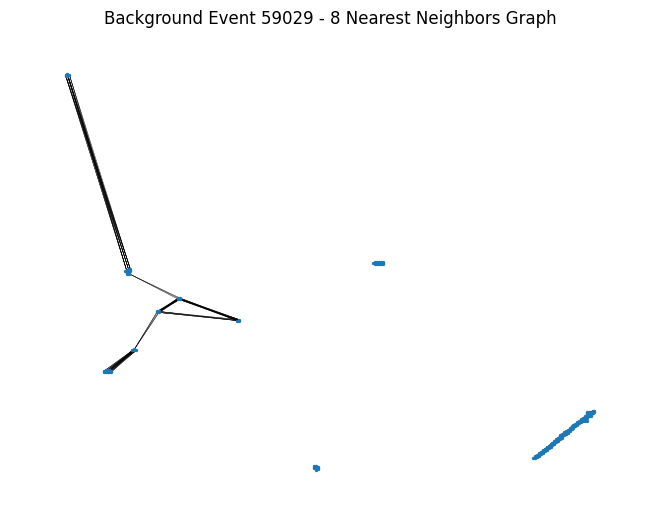

In [ ]:
def make_a_kNN_graph(data_list, event_index, k=8, title_prefix=''):
    sp = data_list[event_index]['spacepoints']
    X = sp[:, :2]  # wire, time

    A_matrix = kneighbors_graph(X, n_neighbors=k, mode='connectivity', include_self=False).toarray()
    edges = np.array(np.nonzero(A_matrix)).T
    G = nx.from_edgelist(edges)

    pos = {i: (X[i, 0], X[i, 1]) for i in range(len(X))}  # wire, time
    nx.draw(G, pos=pos, node_size=2, width=0.3)
    plt.title(f'{title_prefix} Event {event_index} - {k} Nearest Neighbors Graph')
    plt.show()
make_a_kNN_graph(all_data, sig_event_index, k=8, title_prefix='Signal')
make_a_kNN_graph(all_data, bkg_event_index, k=8, title_prefix='Background')

### (Optional) Use plotly to visualise in 3D

Commented out in case you don't have plotly

In [ ]:
# from plotly import graph_objects as go

# def plot_spacepoints_3d(df, event_index, spacepoint_type='recchargeblob', title_prefix=''):
#     event = df.iloc[event_index]

#     true_vtx = (df.iloc[event_index]['truth_vtxX'], df.iloc[event_index]['truth_vtxY'], df.iloc[event_index]['truth_vtxZ'])
#     reco_vtx = (df.iloc[event_index]['reco_nuvtxX'], df.iloc[event_index]['reco_nuvtxY'], df.iloc[event_index]['reco_nuvtxZ'])

#     # Trident events don't have a proper true vertex assigned, so we find the outgoing neutrino ourselves
#     if true_vtx[0] == 0 and true_vtx[1] == 0 and true_vtx[2] == 0:
#         truth_pdg = np.array(df.iloc[event_index]['truth_pdg'])
#         neutrino_index= np.argwhere((truth_pdg == 12) | (truth_pdg == -12) | (truth_pdg == 14) | (truth_pdg == -14) | (truth_pdg == 16) | (truth_pdg == -16))[0]
#         if neutrino_index.size > 0:
#             truth_start = df.iloc[event_index]['truth_startXYZT'][neutrino_index[0]]
#             true_vtx = (truth_start[0], truth_start[1], truth_start[2])
#         else:
#             print("No neutrino found in truth information for this event.")
#             true_vtx = (np.nan, np.nan, np.nan)

#     fig = go.Figure(data=[go.Scatter3d(
#         x=event[f'T{spacepoint_type}_spacepoints_x'],
#         y=event[f'T{spacepoint_type}_spacepoints_y'],
#         z=event[f'T{spacepoint_type}_spacepoints_z'],
#         mode='markers',
#         marker=dict(size=2, color=event[f'T{spacepoint_type}_spacepoints_q'], colorscale='Viridis', opacity=0.8)
#     )])

#     fig.add_trace(go.Scatter3d(
#         x=[true_vtx[0]],
#         y=[true_vtx[1]],
#         z=[true_vtx[2]],
#         mode='markers',
#         marker=dict(size=4, color='cyan', symbol='x'),
#         name='True Vertex'
#     ))

#     fig.add_trace(go.Scatter3d(
#         x=[reco_vtx[0]],
#         y=[reco_vtx[1]],
#         z=[reco_vtx[2]],
#         mode='markers',
#         marker=dict(size=4, color='red', symbol='diamond'),
#         name='Reco Vertex'
#     ))

#     fig.update_layout(
#                         title=f'{title_prefix} Event {event_index} Spacepoints (colored by charge)',
#                         width=800, height=800
#                         )

#     fig.update_scenes(aspectmode = "manual",
#     aspectratio = dict( x = 1, y = 1, z = 1), xaxis_title="X", yaxis_title="Y", zaxis_title="Z")
#     fig.show()

# plot_spacepoints_3d(signal_spacepoints_df, sig_event_index, spacepoint_type=spacepoint_type, title_prefix='Signal')
# plot_spacepoints_3d(background_spacepoints_df, bkg_event_index, spacepoint_type=spacepoint_type, title_prefix='Background')

## Formatting signal and background for loading

Here we turn each event into a graph, and store it in a torch_geometric "Data" object, which is designed to work with graphs and the torch_geometric "DataLoader" later on.

In [ ]:
def printProgressBar (iteration, total, prefix = '', suffix = '', decimals = 1, length = 100, fill = '█', printEnd = "\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end = printEnd)
    # Print New Line on Complete
    if iteration == total:
        print()


def make_spacepoint_array(data_list, n_neighbors=8, device=device):
    data_list_out = []
    N_skipped = 0
    nevents = len(data_list)
    printProgressBar(0, nevents, prefix='Progress:', suffix='Complete', length=50)
    for i, event in enumerate(data_list):
        sp = event['spacepoints']
        label = event['label']
        if len(sp) > n_neighbors + 1:
            A_matrix = kneighbors_graph(sp, n_neighbors=n_neighbors, mode='connectivity', include_self=False).toarray()
        elif len(sp) > 1:
            A_matrix = kneighbors_graph(sp, n_neighbors=min(n_neighbors, len(sp)-1), mode='connectivity', include_self=False).toarray()
        elif len(sp) == 1:
            A_matrix = np.array([[1]])
        else:
            N_skipped += 1
            continue
        edges = np.array(np.nonzero(A_matrix))
        x = torch.tensor(sp, dtype=torch.float).to(device)
        edge_index = torch.tensor(edges, dtype=torch.long).to(device)
        y = torch.tensor([label], dtype=torch.float).to(device)
        data_list_out.append(Data(x=x, edge_index=edge_index, y=y))
        printProgressBar(i+1, nevents, prefix='Progress:', suffix='Complete', length=50)
    print(f'Skipped {N_skipped} events with no spacepoints')
    return data_list_out

In [ ]:
n_neighbors = 8
N_dims = 3  # wire, time, ADC

all_graphs = make_spacepoint_array(all_data, n_neighbors=n_neighbors, device=device)
test_sample = make_spacepoint_array(test_data_raw, n_neighbors=n_neighbors, device=device)

train_sample, val_sample = train_test_split(all_graphs, test_size=0.15, random_state=42)

print(f"Training graphs: {len(train_sample)}")
print(f"Validation graphs: {len(val_sample)}")
print(f"Testing graphs: {len(test_sample)}")

Progress: |██████████████████████████████████████████████████| 100.0% Complete
Skipped 821 events with no spacepoints
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Skipped 104 events with no spacepoints
Training graphs: 52749
Validation graphs: 9309
Testing graphs: 6807


## Creating a Graph Neural Network

In [ ]:
class GNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super(GNNClassifier, self).__init__()
        # input shape (batch, num_nodes, input_dim)

        self.init_batch_norm = BatchNorm(input_dim)

        conv_layers = []
        if isinstance(hidden_dims, int):
            gnn_conv = conv.GraphConv(input_dim, hidden_dims)
            batch_norm = BatchNorm(hidden_dims)
            activation = nn.ReLU()
            conv_layers.append((gnn_conv, batch_norm, activation))
            input_dim = hidden_dims
        else:
            for hidden_dim in hidden_dims:
                gnn_conv = conv.GraphConv(input_dim, hidden_dim)
                batch_norm = BatchNorm(hidden_dim)
                activation = nn.ReLU()
                conv_layers.append((gnn_conv, batch_norm, activation))
                input_dim = hidden_dim
        self.conv_layers = nn.ModuleList([nn.ModuleList(layer) for layer in conv_layers])



        self.output_layer = nn.Linear(input_dim, output_dim)
        self.output_activation = nn.Sigmoid() if output_dim == 1 else nn.Softmax(dim=1)

    def forward(self, data, edges, batch_indices, skip_output_activation=False):
        # We include an option to skip the output activation function because some loss functions (eg BCEWithLogitsLoss) expect raw logits as input.
        x = self.init_batch_norm(data)

        for gnn_conv, batch_norm, activation in self.conv_layers:
            x = gnn_conv(x, edges)
            x = batch_norm(x)
            x = activation(x)

        x = global_mean_pool(x, batch_indices)
        x = self.output_layer(x)

        if not skip_output_activation:
            x = self.output_activation(x)
        return x

In [ ]:
input_dim = N_dims  # x, y, q
conv_layer_dims = [8, 16, 32]

model = GNNClassifier(input_dim=input_dim, hidden_dims=conv_layer_dims, output_dim=1).to(device)

dummy_data = torch.randn((10, input_dim)).to(device)  # 10 nodes, input_dim features
dummy_edges = torch.tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
                            [1, 0, 3, 2, 5, 4, 7, 6, 9, 8]], dtype=torch.long).to(device)  # example edge index
dummy_batch = torch.zeros(10, dtype=torch.long).to(device)  # all nodes belong to the same graph
dummy_nu_vertex = torch.randn((1,3)).to(device)  # example neutrino vertex
torchinfo.summary(model, input_data=(dummy_data, dummy_edges, dummy_batch))

Layer (type:depth-idx)                   Output Shape              Param #
GNNClassifier                            [1, 1]                    --
├─BatchNorm: 1-1                         [10, 3]                   --
│    └─BatchNorm1d: 2-1                  [10, 3]                   6
├─ModuleList: 1-2                        --                        --
│    └─ModuleList: 2-2                   --                        --
│    │    └─GraphConv: 3-1               [10, 8]                   56
│    │    └─BatchNorm: 3-2               [10, 8]                   16
│    │    └─ReLU: 3-3                    [10, 8]                   --
│    └─ModuleList: 2-3                   --                        --
│    │    └─GraphConv: 3-4               [10, 16]                  272
│    │    └─BatchNorm: 3-5               [10, 16]                  32
│    │    └─ReLU: 3-6                    [10, 16]                  --
│    └─ModuleList: 2-4                   --                        --
│    │    └─Gra

In [ ]:
batch_size = 32
nepochs = 10

lr = 1e-3
gamma = 1 # learning rate decay factor, set to 1 to disable decay

optimizer = torch.optim.RAdam(model.parameters(), lr=lr)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)  # Define learning rate scheduler.

if scheduler is not None and gamma != 1:
    print('Using learning rate scheduler with gamma =', gamma)
    x = np.linspace(1, nepochs, nepochs)
    f = lambda l: lr * (gamma ** (l - 1))
    y = f(x)
    plt.plot(x, y)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.show()

train_loader = DataLoader(train_sample, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_sample, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_sample, batch_size=batch_size, shuffle=False)

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

model_states = []

for epoch in range(nepochs):
    print(f'Epoch {epoch+1}/{nepochs}')
    if scheduler is not None and gamma != 1:
        print(f'Learning Rate: {optimizer.param_groups[0]["lr"]:.2e}')
    printProgressBar(0, len(train_loader), prefix = 'Progress:', suffix = 'Complete', length = 50)

    model.train()
    epoch_loss = 0
    epoch_acc = 0
    train_loader = DataLoader(train_sample, batch_size=batch_size, shuffle=True) # Shuffle training data at the beginning of each epoch
    j = 1
    for batch in train_loader:
        optimizer.zero_grad()

        # Note here that we are passing skip_output_activation=True to the model's forward function.
        # This is because we are using BCEWithLogitsLoss as our loss function, which expects
        # raw logits rather than a score between 0 and 1. Using logits in loss leads to more numerically stable training.
        outputs = model(batch.x, batch.edge_index, batch.batch, skip_output_activation=True)
        scores = torch.sigmoid(outputs).squeeze()
        loss = criterion(outputs.squeeze(), batch.y.float())
        loss.backward()
        optimizer.step()

        loss_value = loss.mean().item()
        epoch_loss += loss_value
        acc = ((scores > 0.5) == batch.y).float().mean().item()
        epoch_acc += acc

        printProgressBar(j, len(train_loader), prefix = 'Progress:', suffix = 'Complete', length = 50)
        j += 1
    epoch_loss /= len(train_loader)
    epoch_acc /= len(train_loader)

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    model_states.append(model.state_dict())

    # Validation
    model.eval()
    epoch_val_loss = 0
    epoch_val_acc = 0
    for batch in val_loader:
        with torch.no_grad():
            outputs = model(batch.x, batch.edge_index, batch.batch, skip_output_activation=True)
            scores = torch.sigmoid(outputs).squeeze()
            loss = criterion(outputs.squeeze(), batch.y.float())
            preds = (scores > 0.5).long()
            acc = (preds == batch.y).float().mean().item()
            epoch_val_acc += acc
            epoch_val_loss += loss.mean().item()
    epoch_val_loss /= len(val_loader)
    epoch_val_acc /= len(val_loader)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step() if scheduler is not None and gamma != 1 else None
    print(f"Epoch {epoch+1}/{nepochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")


Epoch 1/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 1/10 - Train Loss: 0.5336, Train Acc: 0.7421, Val Loss: 0.4868, Val Acc: 0.7700
Epoch 2/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 2/10 - Train Loss: 0.4962, Train Acc: 0.7605, Val Loss: 0.4661, Val Acc: 0.7826
Epoch 3/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 3/10 - Train Loss: 0.4860, Train Acc: 0.7659, Val Loss: 0.4615, Val Acc: 0.7849
Epoch 4/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 4/10 - Train Loss: 0.4815, Train Acc: 0.7674, Val Loss: 0.4537, Val Acc: 0.7853
Epoch 5/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 5/10 - Train Loss: 0.4779, Train Acc: 0.7702, Val Loss: 0.4507, Val Acc: 0.7894
Epoch 6/10
Progress: |██████████████████████████████████████████████████| 100.0% Complete
Epoch 6/10 - Train Loss: 0.473

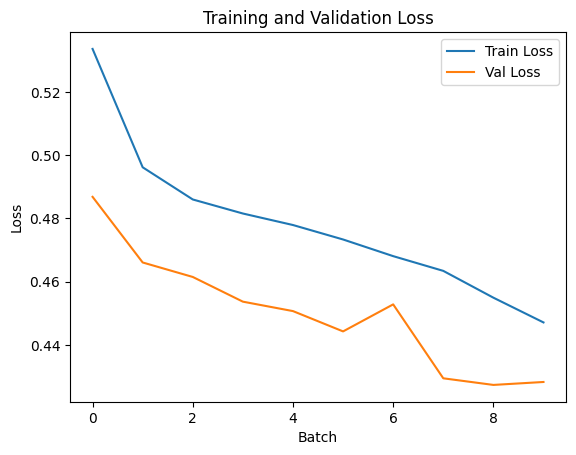

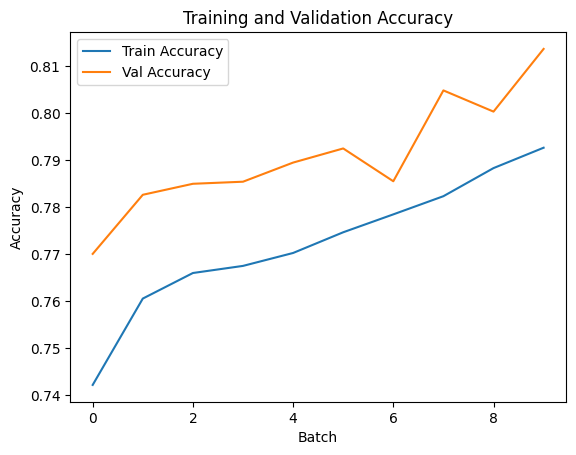

In [ ]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Batch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

## Evaluating the model
### Grabbing the epoch that minimised loss or maxismised accuracy.

Best model found at epoch 9 with validation loss 0.4273 and validation accuracy 0.8003
Test Accuracy: 0.8084


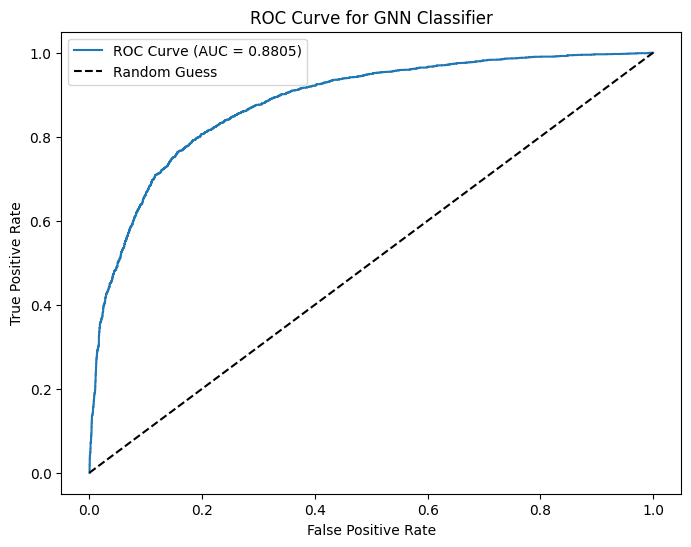

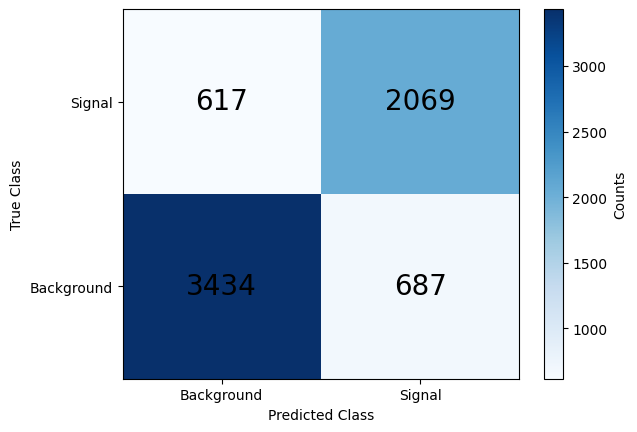

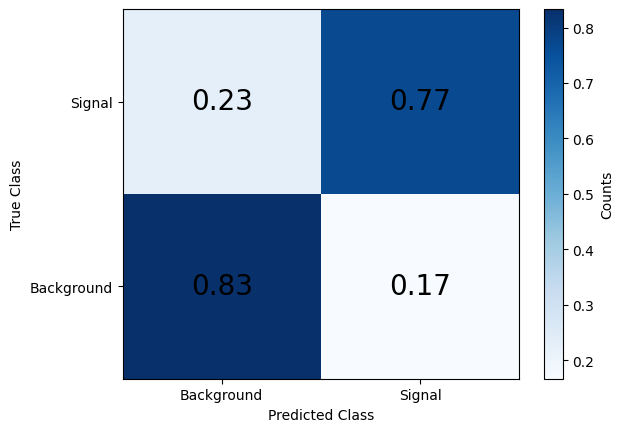

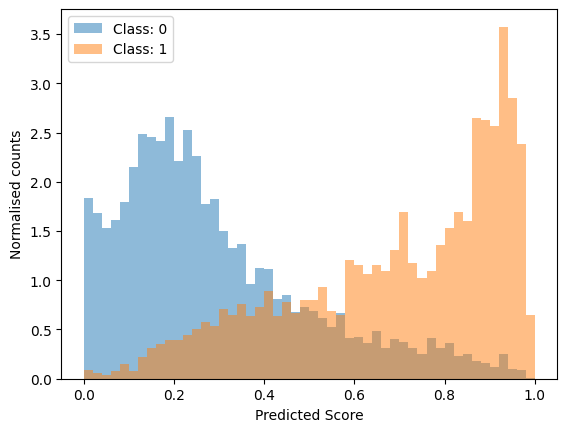

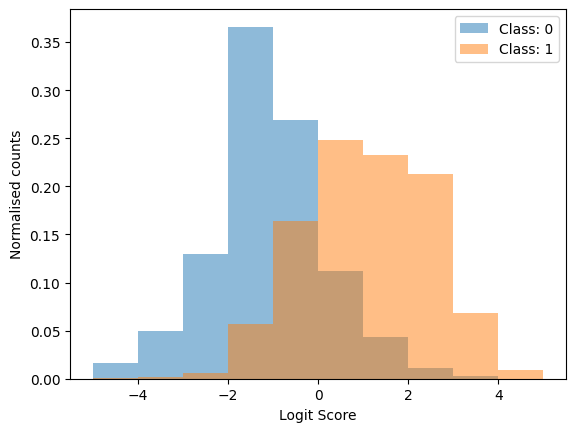

In [ ]:
optimal_epoch = np.argmin(val_losses) # Decide how to choose the optimal epoch - np.argmin(val_losses) or np.argmax(val_accuracies)
print(f"Best model found at epoch {optimal_epoch+1} with validation loss {val_losses[optimal_epoch]:.4f} and validation accuracy {val_accuracies[optimal_epoch]:.4f}")
best_model_state = model_states[optimal_epoch]
model.load_state_dict(best_model_state)


test_flags = []
test_scores = []
for batch in test_loader:
    model.eval()
    with torch.no_grad():
        outputs = model(batch.x, batch.edge_index, batch.batch, skip_output_activation=True)
        scores = torch.sigmoid(outputs).squeeze()
        test_scores.extend(scores.cpu().numpy())
        test_flags.extend(batch.y.cpu().numpy())

test_acc = ((np.array(test_scores) > 0.5) == np.array(test_flags)).mean()
print(f"Test Accuracy: {test_acc:.4f}")

roc_curve = metrics.roc_curve(test_flags, test_scores)
auc_score = metrics.auc(roc_curve[0], roc_curve[1])

plt.figure(figsize=(8, 6))
plt.plot(roc_curve[0], roc_curve[1], label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for GNN Classifier')
plt.legend()
plt.show()

predicted_class = (np.array(test_scores) >= 0.5).astype(int)
confusion_matrix_arrs = metrics.confusion_matrix(test_flags, predicted_class)
norm_conf_matrix = confusion_matrix_arrs / np.sum(confusion_matrix_arrs, axis=1, keepdims=True)

plt.pcolormesh(confusion_matrix_arrs, cmap='Blues', shading='auto')
plt.xticks([0.5, 1.5], ['Background', 'Signal'])
plt.yticks([0.5, 1.5], ['Background', 'Signal'])
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.5, confusion_matrix_arrs[i, j], ha='center', va='center', color='black', fontsize=20)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.colorbar(label='Counts')
plt.show()

plt.pcolormesh(norm_conf_matrix, cmap='Blues', shading='auto')
plt.xticks([0.5, 1.5], ['Background', 'Signal'])
plt.yticks([0.5, 1.5], ['Background', 'Signal'])
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.5, f'{norm_conf_matrix[i, j]:.2f}', ha='center', va='center', color='black', fontsize=20)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.colorbar(label='Counts')
plt.show()


bins = np.linspace(0, 1, 51)
for cls_type in np.unique(test_flags):
    cls_mask = np.array(test_flags) == cls_type
    cls_preds = np.array(test_scores)[cls_mask]
    plt.hist(cls_preds, bins=bins, alpha=0.5, density=True, label=f'Class: {int(cls_type)}')
plt.xlabel('Predicted Score')
plt.ylabel('Normalised counts')
plt.legend()
plt.show()

logit_score = np.log(np.array(test_scores) / (1 - np.array(test_scores)))
bins = np.linspace(-5, 5, 11)
for cls_type in np.unique(test_flags):
    cls_mask = np.array(test_flags) == cls_type
    cls_preds = logit_score[cls_mask]
    plt.hist(cls_preds, bins=bins, alpha=0.5, density=True, label=f'Class: {int(cls_type)}')
plt.xlabel('Logit Score')
plt.ylabel('Normalised counts')
plt.legend()
plt.show()

## Testing on Nu Overlay

How does this perform on the full nu overlay background sample?

In [ ]:
overlay_name = "/exp/uboone/data/users/jbateman/workdir/DarkNews/newSamplesWCepem/mcc910/checkout_MCC9.10_Run4b_v10_04_07_09_BNB_nu_overlay_surprise_reco2_hist.root"
nentries_overlay = 1000
print("Loading overlay spacepoints...")
overlay_spacepoints_df = generic_neutrino_selection_spacepoints_vars(uproot.open(overlay_name), nentries=nentries_overlay, spacepoint_type=spacepoint_type)
print("Turning overlay sample into graphs...")
overlay_data_list = make_spacepoint_array(overlay_spacepoints_df, use_q=use_q, flag=-1, radius_cut=radius_cut, n_neighbors=n_neighbors, spacepoint_type=spacepoint_type, device=device)
print(f"Overlay sample complete. Number of graphs: {len(overlay_data_list)}")
overlay_loader = DataLoader(overlay_data_list, batch_size=batch_size, shuffle=False)

Loading overlay spacepoints...


NameError: name 'generic_neutrino_selection_spacepoints_vars' is not defined

In [ ]:
overlay_scores = []
for batch in overlay_loader:
    model.eval()
    with torch.no_grad():
        outputs = model(batch.x, batch.edge_index, batch.batch, skip_output_activation=True)
        scores = torch.sigmoid(outputs).squeeze()
        overlay_scores.extend(scores.cpu().numpy())

bins = np.linspace(0, 1, 51)

plt.hist(overlay_scores, bins=bins, alpha=0.5, density=True, label=f'Nu Overlay (background only)')
plt.xlabel('Predicted Score')
plt.ylabel('Normalised counts')
plt.legend(title=f'Frac > 0.5: {sum(np.array(overlay_scores) > 0.5) / len(overlay_scores):.2f}')
plt.show()